In [5]:
path = 'C:/Users/noturno/MachineLearning/datasets/'

In [2]:
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df_co2 = pd.read_csv(path + 'ConsumoxCo2.csv')

In [7]:
df_co2.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [8]:
df_co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [9]:
df_co2.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [10]:
X_co2 = df_co2.drop(['MAKE', 'MODEL', 'VEHICLECLASS', 'FUELTYPE', 'TRANSMISSION'], axis=1)
y_co2 = df_co2['CO2EMISSIONS']

In [11]:
X_co2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   ENGINESIZE                1067 non-null   float64
 2   CYLINDERS                 1067 non-null   int64  
 3   FUELCONSUMPTION_CITY      1067 non-null   float64
 4   FUELCONSUMPTION_HWY       1067 non-null   float64
 5   FUELCONSUMPTION_COMB      1067 non-null   float64
 6   FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 7   CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 66.8 KB


In [12]:
# metodo SHUFFLE embaralha os dados para depois fazer a repartição dos mesmos, fazendo assim de forma aleatoria
X_train_co2, X_test_co2, y_train_co2, y_test_co2 = train_test_split(
    X_co2, y_co2, test_size = 0.3, shuffle = True, random_state = 0)

In [13]:
X_train_co2.shape, X_test_co2.shape, y_train_co2.shape, y_test_co2.shape

((746, 8), (321, 8), (746,), (321,))

In [14]:
#modelo regressao
modelo_dt = DecisionTreeRegressor()

In [15]:
#treinando o modelo
modelo_dt = modelo_dt.fit(X_train_co2, y_train_co2)

In [16]:
modelo_dt_preds = modelo_dt.predict(X_test_co2)

[Text(0.501842248908297, 0.9545454545454546, 'x[7] <= 270.5\nsquared_error = 4012.852\nsamples = 746\nvalue = 258.66'),
 Text(0.2534115720524017, 0.8636363636363636, 'x[7] <= 215.0\nsquared_error = 1072.482\nsamples = 455\nvalue = 217.47'),
 Text(0.37762691048034935, 0.9090909090909092, 'True  '),
 Text(0.1331877729257642, 0.7727272727272727, 'x[7] <= 183.0\nsquared_error = 353.221\nsamples = 208\nvalue = 187.12'),
 Text(0.05949781659388646, 0.6818181818181818, 'x[7] <= 160.0\nsquared_error = 215.827\nsamples = 77\nvalue = 167.584'),
 Text(0.019650655021834062, 0.5909090909090909, 'x[5] <= 5.75\nsquared_error = 153.802\nsamples = 18\nvalue = 145.444'),
 Text(0.008733624454148471, 0.5, 'x[3] <= 4.95\nsquared_error = 81.0\nsamples = 2\nvalue = 117.0'),
 Text(0.004366812227074236, 0.4090909090909091, 'squared_error = 0.0\nsamples = 1\nvalue = 108.0'),
 Text(0.013100436681222707, 0.4090909090909091, 'squared_error = 0.0\nsamples = 1\nvalue = 126.0'),
 Text(0.03056768558951965, 0.5, 'x[7] <

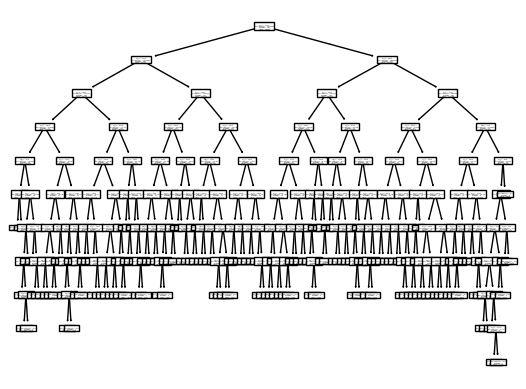

In [17]:
#gerando arvore
tree.plot_tree(modelo_dt)

In [18]:
from sklearn import linear_model
import seaborn as sns

In [19]:
df_selecao = df_co2[['ENGINESIZE', 'CO2EMISSIONS']]

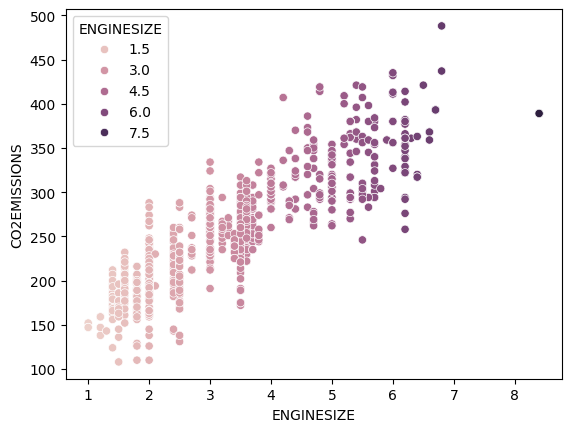

In [20]:
rl = sns.scatterplot(x = 'ENGINESIZE', y = 'CO2EMISSIONS', data = df_selecao,
                     hue = 'ENGINESIZE')

In [21]:
len(df_selecao)

1067

In [22]:
treino1 = df_selecao[:(int(len(df_selecao)*0.7))]
teste1 = df_selecao[:(int(len(df_selecao)*0.7)):]

In [23]:
treino1.shape, teste1.shape

((746, 2), (746, 2))

In [25]:
modelo_rl1 = linear_model.LinearRegression()

In [26]:
import numpy as np

In [28]:
treino_X = np.array(treino1[['ENGINESIZE']])
treino_y = np.array(treino1[['CO2EMISSIONS']])

In [29]:
modelo_rl1.fit(treino_X,treino_y)

LinearRegression()

In [30]:
modelo_rl1.coef_, modelo_rl1.intercept_

(array([[39.24284192]]), array([125.79093758]))

In [31]:
import matplotlib.pyplot as plt

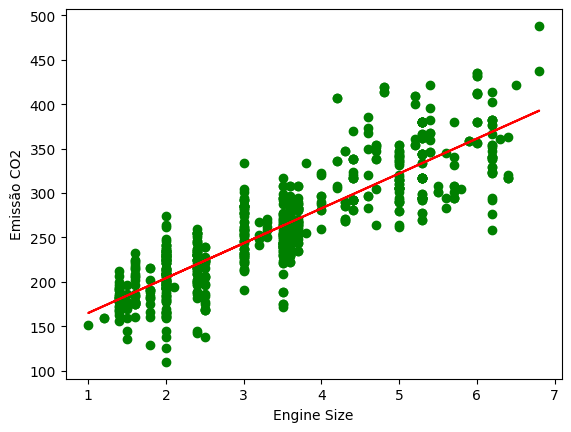

In [33]:
plt.scatter(treino1['ENGINESIZE'], treino1['CO2EMISSIONS'], color ='green')
plt.plot(treino_X, modelo_rl1.coef_*treino_X + modelo_rl1.intercept_, '-r')
plt.xlabel('Engine Size')
plt.ylabel('Emissão CO2')
plt.show()



In [35]:
def predicao_co2(dado, intercept, angulo):
    pred = dado * angulo + intercept
    return pred

In [36]:
potencia = 1.8
emissao_estimada =  predicao_co2(potencia,
                                 modelo_rl1.intercept_[0],
                                 modelo_rl1.coef_[0][0])
print('A emissão de Co2 para o veículo de potência', potencia, 'é: ', emissao_estimada)


A emissão de Co2 para o veículo de potência 1.8 é:  196.4280530325115


In [37]:
import numpy as np
from sklearn.datasets import load_digits
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [38]:
digitos = load_digits()

In [40]:
len(digitos.feature_names)

64

In [42]:
digitos.target

array([0, 1, 2, ..., 8, 9, 8])

In [43]:
digitos.target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
digitos.images

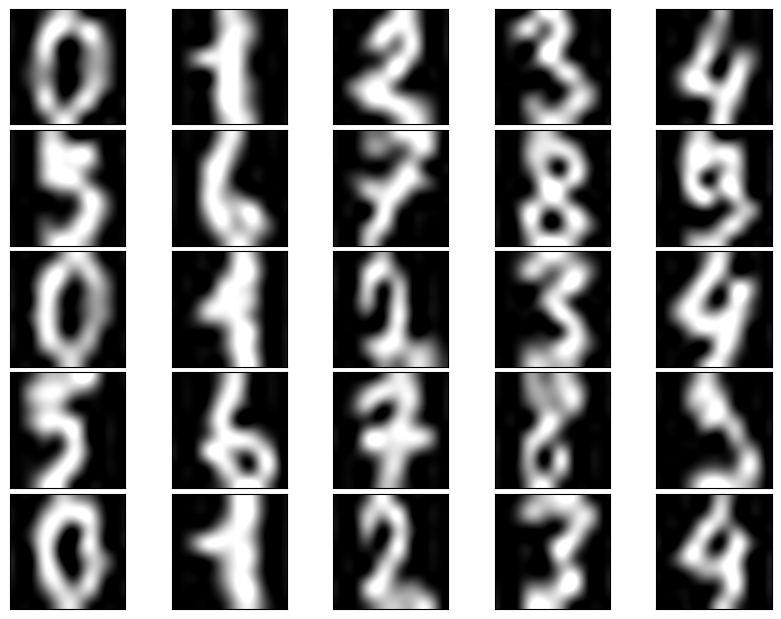

In [47]:
fig = plt.figure(figsize =(8,6))
fig.subplots_adjust(left =0, right =1, bottom =0, top=1,
                    hspace=0.05, wspace= 0.05)
for i in range(25):
    ax = fig.add_subplot(5, 5, i +1, xticks =[], yticks =[])
    ax.imshow(digitos.images[i], cmap = plt.cm.gray, interpolation= 'lanczos')
